In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# 1. Image Transformations (Grayscale images only need 1 channel normalization)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)) # Standard mean and std for MNIST
])

print("Attempting to load MNIST dataset...")

# 2. Load Train and Test sets
train_dataset = torchvision.datasets.MNIST(
    root='./mnist_data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./mnist_data',
    train=False,
    download=True,
    transform=transform
)

# 3. Create DataLaoders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("\n" + "="*35)
print(" Success! Dataset Loaded Cleanly.")
print(f"Training images: {len(train_dataset)}")
print(f"Testing images: {len(test_dataset)}")
print("="*35)

Attempting to load MNIST dataset...

 Success! Dataset Loaded Cleanly.
Training images: 60000
Testing images: 10000


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class MNISTCNN(nn.Module):
    def __init__(self):
        super(MNISTCNN, self).__init__()

        # --- Feature Extraction ---
        # Input Channel: 1 (Grayscale), Output Channels: 16, Filter Size: 3x3, Padding: 1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)

        # Input Channel: 16, Output Channels: 32, Filter Size: 3x3, Padding: 1
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        # Max Pooling: Har image ki Width aur Height ko aadha (half) kar deta hai
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- Classification Head ---
        # 2 dafa pooling ke baad, 28x28 ki image 7x7 ban jayegi.
        # Total flattened features: 32 channels * 7 width * 7 height = 1568
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10) # 10 outputs (0 se le kar 9 tak ke digits)

    def forward(self, x):
        # Block 1: Conv1 -> ReLU -> MaxPool
        # Input: [64, 1, 28, 28] -> Conv1 -> [64, 16, 28, 28] -> Pool -> [64, 16, 14, 14]
        x = self.pool(F.relu(self.conv1(x)))

        # Block 2: Conv2 -> ReLU -> MaxPool
        # Input: [64, 16, 14, 14] -> Conv2 -> [64, 32, 14, 14] -> Pool -> [64, 32, 7, 7]
        x = self.pool(F.relu(self.conv2(x)))

        # Flattening: Multidimensional matrix ko 1D vector mein convert karna array per image
        # Output shape: [64, 1568]
        x = x.view(-1, 32 * 7 * 7)

        # Fully Connected Layer 1 + Activation
        x = F.relu(self.fc1(x))

        # Final Output Layer (Raw scores / Logits for 10 classes)
        x = self.fc2(x)
        return x

# Model ko initialize karna aur check karna
model = MNISTCNN()
print(model)

MNISTCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
import torch.optim as optim

# ==========================================
# STEP 3: Setup Device, Loss aur Optimizer
# ==========================================

# Check karte hain agar Colab ka GPU available hai, nahi to CPU use hoga
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Model ko GPU/CPU par shift karna
model = model.to(device)

# Loss Function: Multi-class classification ke liye CrossEntropyLoss best hai
criterion = nn.CrossEntropyLoss()

# Optimizer: Adam optimizer weights ko jaldi aur smartly update karta hai
# lr (Learning Rate) = 0.001 matlab model aahista aur dhyan se seekhega
optimizer = optim.Adam(model.parameters(), lr=0.001)


# ==========================================
# STEP 4: The Training Loop
# ==========================================

epochs = 3 # Pura dataset model se 3 dafa guzre ga

print("Training shuru ho rahi hai...")
for epoch in range(epochs):
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # train_loader se data batches mein aayega
    for batch_idx, (images, labels) in enumerate(train_loader):

        # 1. Data ko GPU/Device par bhejna
        images = images.to(device)
        labels = labels.to(device)

        # 2. Purane Gradients ko zero karna (bohot zaroori hai!)
        optimizer.zero_grad()

        # 3. Forward Pass: Model se prediction nikalwana
        outputs = model(images)

        # 4. Loss Calculate karna (Model kitna ghalat hai)
        loss = criterion(outputs, labels)

        # 5. Backward Pass: Ghaltiyan peche ki taraf bhejna (Backpropagation)
        loss.backward()

        # 6. Weights Update karna: Optimizer weights ko theek karega
        optimizer.step()

        # --- Stats Calculation ---
        running_loss += loss.item()

        # Accuracy check karne ke liye max score wala digit nikalna
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

        # Har 200 batches baad progress print karna
        if (batch_idx + 1) % 200 == 0:
            current_loss = running_loss / 200
            current_acc = (correct_predictions / total_samples) * 100
            print(f"Epoch [{epoch+1}/{epochs}], Batch [{batch_idx+1}/{len(train_loader)}], "
                  f"Loss: {current_loss:.4f}, Accuracy: {current_acc:.2f}%")

            # Reset stats for next 200 batches
            running_loss = 0.0

print("\n" + "="*35)
print("🎉 Training Complete Ho Gayi!")
print("="*35)

Using device: cpu
Training shuru ho rahi hai...
Epoch [1/3], Batch [200/938], Loss: 0.3877, Accuracy: 88.46%
Epoch [1/3], Batch [400/938], Loss: 0.1178, Accuracy: 92.45%
Epoch [1/3], Batch [600/938], Loss: 0.0897, Accuracy: 94.03%
Epoch [1/3], Batch [800/938], Loss: 0.0732, Accuracy: 94.96%
Epoch [2/3], Batch [200/938], Loss: 0.0559, Accuracy: 98.38%
Epoch [2/3], Batch [400/938], Loss: 0.0454, Accuracy: 98.46%
Epoch [2/3], Batch [600/938], Loss: 0.0428, Accuracy: 98.55%
Epoch [2/3], Batch [800/938], Loss: 0.0448, Accuracy: 98.57%
Epoch [3/3], Batch [200/938], Loss: 0.0373, Accuracy: 98.96%
Epoch [3/3], Batch [400/938], Loss: 0.0309, Accuracy: 99.02%
Epoch [3/3], Batch [600/938], Loss: 0.0317, Accuracy: 99.02%
Epoch [3/3], Batch [800/938], Loss: 0.0345, Accuracy: 98.98%

🎉 Training Complete Ho Gayi!


In [ ]:
# Check karte hain ke unseen testing data par accuracy kya aati hai
correct = 0
total = 0

# PyTorch ko bolna ke ab gradients calculate karne ki zaroori nahi hai (Validation mode)
with torch.no_grad():
    for images, labels in test_loader:
        # Data ko GPU/CPU par bhejna
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass: Model se prediction lena
        outputs = model(images)

        # Jis class ka score sab se zyada ho, usko prediction manna
        _, predicted = torch.max(outputs.data, 1)

        # Total samples aur sahi predictions ko jama (accumulate) karna
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# Final accuracy calculate karna
final_accuracy = (correct / total) * 100

print("="*40)
print(f"📊 Final Test Accuracy on 10,000 Unseen Images: {final_accuracy:.2f}%")
print("="*40)

📊 Final Test Accuracy on 10,000 Unseen Images: 99.00%


In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Apni handwritten digit ki image (0-9) upload karein:")
uploaded = files.upload()

for filename in uploaded.keys():
    # 1. Image ko grayscale (Black & White) mein load karna
    img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

    # 2. Image ka size change karke exact 28x28 pixels karna (MNIST size)
    img_resized = cv2.resize(img, (28, 28))

    # 3. CRITICAL STEP: Agar aapne white paper par black pen se likha hai,
    # to humen colors ko invert (ulat) karna hoga, kyunke MNIST mein background black hota hai.
    # Hum check karte hain agar center ka pixel corner se bright hai to invert zaroori hai.
    if np.mean(img_resized[0:4, 0:4]) > 127:
        img_resized = cv2.bitwise_not(img_resized)

    # 4. Data ko normalize karna (0-1 range mein lana aur standard mean/std lagana)
    img_normalized = img_resized.astype(np.float32) / 255.0
    img_normalized = (img_normalized - 0.1307) / 0.3081

    # 5. Model ke liye dimensions set karna: [Batch=1, Channels=1, Height=28, Width=28]
    test_tensor = torch.tensor(img_normalized).unsqueeze(0).unsqueeze(0)

    # Preprocessed image ko screen par dikhana
    plt.imshow(img_resized, cmap='gray')
    plt.title("Model ko yeh image dikh rahi hai")
    plt.axis('off')
    plt.show()

    print("Image successfully preprocess ho gayi!")

Apni handwritten digit ki image (0-9) upload karein:


In [ ]:
# Model ko evaluation mode mein dalna
model.eval()

# Gradients block karna taake fast run ho
with torch.no_grad():
    # Tensor ko GPU/CPU par bhejna jahan model mojud hai
    test_tensor = test_tensor.to(device)

    # Forward Pass: Model se prediction lena
    outputs = model(test_tensor)

    # Softmax apply karna taake humen percentage (probability) mil sake
    probabilities = torch.nn.functional.softmax(outputs, dim=1)

    # Sab se highest score wala index nikalna
    confidence, predicted_class = torch.max(probabilities, 1)

print("="*40)
print(f"🔮 Model Prediction: {predicted_class.item()}")
print(f"🎯 Confidence Score: {confidence.item() * 100:.2f}%")
print("="*40)

🔮 Model Prediction: 9
🎯 Confidence Score: 38.59%


In [ ]:
import torch

# Model ke weights ko 'mnist_cnn.pth' naam ki file mein save karna
torch.save(model.state_dict(), 'mnist_cnn.pth')

print("="*40)
print("🎉 Model successfully save ho gaya hai!")
print("Colab ke left side par 'Files' folder mein 'mnist_cnn.pth' check karein.")
print("="*40)

🎉 Model successfully save ho gaya hai!
Colab ke left side par 'Files' folder mein 'mnist_cnn.pth' check karein.


<IPython.core.display.Javascript object>

Photo saved to photo.jpg


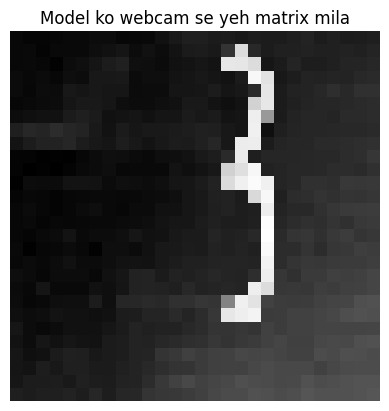


🔮 Webcam Prediction: 3
🎯 Confidence: 37.33%


In [ ]:
try:
  # 1. Webcam se photo lena
  filename = take_photo()
  print(f'Photo saved to {filename}')

  # 2. Preprocessing
  img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
  img_resized = cv2.resize(img, (28, 28))

  if np.mean(img_resized[0:4, 0:4]) > 127:
      img_resized = cv2.bitwise_not(img_resized)

  img_normalized = img_resized.astype(np.float32) / 255.0
  img_normalized = (img_normalized - 0.1307) / 0.3081
  test_tensor = torch.tensor(img_normalized).unsqueeze(0).unsqueeze(0).to(device)

  # === YAHAN HAMNE PLT.IMSHOW ADD KAR DIYA ===
  # Is se aapko dikhega ke webcam ki photo 28x28 banne ke baad kaisi lag rahi hai
  import matplotlib.pyplot as plt
  plt.imshow(img_resized, cmap='gray')
  plt.title("Model ko webcam se yeh matrix mila")
  plt.axis('off')
  plt.show()
  # ==========================================

  # 3. Live Prediction
  model.eval()
  with torch.no_grad():
      outputs = model(test_tensor)
      probabilities = torch.nn.functional.softmax(outputs, dim=1)
      confidence, predicted_class = torch.max(probabilities, 1)

  print("\n" + "="*40)
  print(f"🔮 Webcam Prediction: {predicted_class.item()}")
  print(f"🎯 Confidence: {confidence.item() * 100:.2f}%")
  print("="*40)

except Exception as err:
  print(str(err))